# Optimization Methods for the LASSO Problem

**Optimization for Data Science — University of Padova**  
Group project comparing Classic Frank-Wolfe, Pairwise Frank-Wolfe, and Projected Gradient for L1-constrained least squares.

**Contributors:** Berke Kaan Dede, Erdem Altun, Andela Ruta Stancu


## Pairwise Frank-Wolfe — Berke Kaan Dede


In [ ]:
import os
import shutil
import ssl
import urllib.request
import zipfile
import bz2
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_svmlight_file
from sklearn.preprocessing import StandardScaler


def load_riboflavin():
  print("loading riboflavin...")
  data = fetch_openml(name="riboflavin", version=1, parser="auto")
  X = np.array(data.data, dtype=np.float64)
  Y = np.array(data.target, dtype=np.float64)

  scaler = StandardScaler()
  X = scaler.fit_transform(X)
  Y = Y - np.mean(Y)
  return X, Y


def load_msd():
  print("loading msd...")
  msd_url = (
      "https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip"
  )
  if not os.path.exists("YearPredictionMSD.txt"):
    urllib.request.urlretrieve(msd_url, "temp.zip")
    z = zipfile.ZipFile("temp.zip", "r")
    z.extractall(".")
    z.close()
    os.remove("temp.zip")

  df_msd = pd.read_csv("YearPredictionMSD.txt", header=None)
  Y = df_msd.iloc[:, 0].values.astype(float)
  X = df_msd.iloc[:, 1:].values.astype(float)

  scaler = StandardScaler()
  X = scaler.fit_transform(X)
  Y = Y - np.mean(Y)
  return X, Y


def load_e2006():
    print("loading e2006...")

    e_url = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/regression/E2006.train.bz2"

    if not os.path.exists("E2006.train"):

        # SSL context for Python 3.13
        ssl_context = ssl.create_default_context()

        if hasattr(ssl, "VERIFY_X509_STRICT"):
            ssl_context.verify_flags &= ~ssl.VERIFY_X509_STRICT

        # Download dataset
        with urllib.request.urlopen(e_url, context=ssl_context) as response:
            with open("temp.bz2", "wb") as out_file:
                shutil.copyfileobj(response, out_file)

        # Decompress dataset
        with bz2.BZ2File("temp.bz2", "rb") as f:
            with open("E2006.train", "wb") as out_file:
                out_file.write(f.read())

        os.remove("temp.bz2")

    # Load dataset
    X, Y = load_svmlight_file("E2006.train")

    # Standardize sparse features
    scaler = StandardScaler(with_mean=False)
    X = scaler.fit_transform(X)

    # Center target
    Y = Y - np.mean(Y)

    return X, Y


# Datasets

# Riboflavin dataset
X1, Y1 = load_riboflavin()

# YearPredictionMSD dataset
X2, Y2 = load_msd()

# E2006 dataset
X3, Y3 = load_e2006()


loading riboflavin...
loading msd...
loading e2006...


In [ ]:
import numpy as np
import time

def pairwise_fw(A, b, tau, tolerance, max_iter, progress_every):
    """
    Solves the L1-constrained least squares problem (LASSO formulation) using
    the Pairwise Frank-Wolfe (PFW) algorithm.

    Problem formulation:
        min_{x} ||A x - b||^2   subject to   ||x||_1 <= tau

    Pairwise FW avoids the classic FW 'zigzagging' phenomenon by simultaneously
    moving weight from an unfavorable active atom (away vertex) to the steepest
    descent atom (forward vertex).
    """

    # Trackers for convergence analysis and plotting
    objective_history = []
    gap_history = []
    alpha_history = []
    runtime_history = []
    nonzero_history = []

    p = A.shape[1]                    # Total number of features (dimension of x)
    x = np.zeros(p)                   # Start at origin x_0 = 0 (feasible inside L1 ball)
    r = -b.copy()                     # Maintain residual r = A@x - b efficiently (initially -b)
    active_set = {"origin": 1.0}      # Track active vertices in the convex decomposition: {vertex_key: weight}

    start_time = time.perf_counter()
    alpha = None

    for k in range(max_iter + 1):
        # ---------------------------------------------------------------------
        # Gradient Computation: grad f(x) = 2 * A^T * (Ax - b) = 2 * A^T * r
        # ---------------------------------------------------------------------
        g = 2 * (A.T @ r)

        # ---------------------------------------------------------------------
        # 1. Forward Frank-Wolfe Vertex Selection (s_k)
        # Solve Linear Minimization Oracle (LMO): min_{s in C} <g, s>
        # Over the L1 ball of radius tau, the minimum is achieved at a corner (extreme point)
        # corresponding to the largest coordinate magnitude of the gradient.
        # ---------------------------------------------------------------------
        j_fw = np.argmax(np.abs(g))             # Coordinate with highest absolute gradient
        sign_fw = -np.sign(g[j_fw])             # Move opposite to gradient direction
        s_key = (j_fw, sign_fw)                 # Unique identifier for the forward atom

        # ---------------------------------------------------------------------
        # Convergence Metrics: Duality Gap & Objective Value
        # Dual Gap: max_{s in C} <g, x - s> = <g, x> + tau * ||g||_inf
        # Objective Value: f(x) = ||Ax - b||^2 = ||r||^2
        # ---------------------------------------------------------------------
        gap = np.dot(g, x) + tau * np.abs(g[j_fw])
        objective = np.dot(r, r)

        # Record iteration history
        objective_history.append(objective)
        gap_history.append(gap)
        runtime_history.append(time.perf_counter() - start_time)
        nonzero_history.append(np.count_nonzero(np.abs(x) > 1e-8))

        # Periodic logging of progress
        if k > 0 and k % progress_every == 0:
            print("Iteration:", k)
            print("Objective value:", objective)
            print("FW gap:", gap)
            print("Alpha:", alpha)
            print()

        # Stopping condition checks
        if gap <= tolerance:                    # Optimality reached within specified gap tolerance
            break
        if k == max_iter:
            break

        # ---------------------------------------------------------------------
        # 2. Away Vertex Selection (v_k)
        # Choose the active vertex from our current expansion that maximizes <g, v>,
        # i.e., the vertex that contributes most negatively to objective reduction.
        # ---------------------------------------------------------------------
        v_key = max(
            active_set.keys(),
            key=lambda key: 0.0 if key == "origin" else g[key[0]] * key[1] * tau,
        )

        # ---------------------------------------------------------------------
        # 3. Pairwise Direction Construction: d = s_k - v_k
        # And compute its image under A: Ad = A @ s_k - A @ v_k
        # Using sparse/dense column extraction for computational efficiency.
        # ---------------------------------------------------------------------
        d = np.zeros(p)

        # Add forward vertex contribution to direction
        d[j_fw] += sign_fw * tau
        col_fw = A[:, j_fw].toarray().ravel() if hasattr(A, "toarray") else A[:, j_fw]
        Ad = col_fw * (sign_fw * tau)

        # Subtract away vertex contribution if it is not the origin
        if v_key != "origin":
            j_away, sign_away = v_key
            d[j_away] -= sign_away * tau
            col_away = A[:, j_away].toarray().ravel() if hasattr(A, "toarray") else A[:, j_away]
            Ad -= col_away * (sign_away * tau)

        # Maximum allowed step size to prevent negative weights in the active set expansion
        alpha_max = active_set[v_key]

        # ---------------------------------------------------------------------
        # 4. Exact Line Search & Step Clipping
        # Minimize f(x + alpha * d) over [0, alpha_max]
        # Quadratic minimization yields: alpha_opt = - <r, Ad> / ||Ad||^2
        # ---------------------------------------------------------------------
        denom = np.dot(Ad, Ad)                  # Scale of curvature along direction d
        if denom <= 1e-15:                      # Numerical stability check (zero curvature)
            break
        alpha = np.clip(-np.dot(r, Ad) / denom, 0.0, alpha_max)
        alpha_history.append(alpha)

        # ---------------------------------------------------------------------
        # 5. State Updates
        # Update solution vector: x_{k+1} = x_k + alpha * d
        # Update residual vector: r_{k+1} = r_k + alpha * Ad
        # ---------------------------------------------------------------------
        x += alpha * d
        r += alpha * Ad

        # ---------------------------------------------------------------------
        # 6. Active Set Weight Transfer & Pruning
        # Shift mass 'alpha' from away vertex v_k to forward vertex s_k.
        # Remove any vertex whose convex weight drops to zero (pruning).
        # ---------------------------------------------------------------------
        active_set[s_key] = active_set.get(s_key, 0.0) + alpha
        active_set[v_key] -= alpha
        if active_set[v_key] <= 1e-12:          # Prune inactive vertex
            del active_set[v_key]

    end_time = time.perf_counter()
    runtime = end_time - start_time

    return x, objective_history, gap_history, alpha_history, runtime, runtime_history, nonzero_history


In [ ]:
# Pairwise Frank-Wolfe for Riboflavin

tau_r = 3.0

x_r, objective_r, gap_r, _, runtime_r, runtime_hist_r, nonzero_r = pairwise_fw(
    X1, Y1, tau_r, tolerance=1e-5, max_iter=5000, progress_every=1000
)

print(f"Final objective:    {objective_r[-1]}")
print(f"Final FW gap:       {gap_r[-1]}")
print(f"Iterations:         {len(objective_r) - 1}")
print(f"Runtime:            {runtime_r:.4f}s")
print(f"L1 norm:            {np.linalg.norm(x_r, 1)}")
print(f"Non-zero coefs:     {np.sum(np.abs(x_r) > 1e-8)}")


Iteration: 1000
Objective value: 0.06904019289890392
FW gap: 0.22645873058142496
Alpha: 0.00015614420134524437

Iteration: 2000
Objective value: 0.046070555622992435
FW gap: 0.12202767672211068
Alpha: 0.00011282666754617455

Iteration: 3000
Objective value: 0.035212391996724525
FW gap: 0.10229706830807306
Alpha: 7.31252946835433e-05

Iteration: 4000
Objective value: 0.028995138974790446
FW gap: 0.07650513569465778
Alpha: 5.000298840914224e-05

Iteration: 5000
Objective value: 0.02622199532656096
FW gap: 0.03431929469711714
Alpha: 3.5445164019062475e-05

Final objective:    0.02622199532656096
Final FW gap:       0.03431929469711714
Iterations:         5000
Runtime:            0.6742s
L1 norm:            3.0000000000000004
Non-zero coefs:     83


In [ ]:
# Pairwise Frank-Wolfe setup for YearPredictionMSD

tau_m = 10.0

x_m, objective_m, gap_m, _, runtime_m, runtime_hist_m, nonzero_m = pairwise_fw(
    X2, Y2, tau_m, tolerance=1e-5, max_iter=3000, progress_every=500
)

print(f"Final objective:    {objective_m[-1]}")
print(f"Final FW gap:       {gap_m[-1]}")
print(f"Iterations:         {len(objective_m) - 1}")
print(f"Runtime:            {runtime_m:.4f}s")
print(f"L1 norm:            {np.linalg.norm(x_m, 1)}")
print(f"Non-zero coefs:     {np.sum(np.abs(x_m) > 1e-8)}")



Final objective:    51260896.55639085
Final FW gap:       9.041279554367065e-06
Iterations:         263
Runtime:            4.5518s
L1 norm:            9.999999999999998
Non-zero coefs:     20


In [ ]:
# Pairwise Frank-Wolfe setup for E2006
tau_e = 3.0

x_e, objective_e, gap_e, _, runtime_e, runtime_hist_e, nonzero_e = pairwise_fw(
    X3, Y3, tau_e, tolerance=1e-5, max_iter=3000, progress_every=500
)

print(f"Final objective:    {objective_e[-1]}")
print(f"Final FW gap:       {gap_e[-1]}")
print(f"Iterations:         {len(objective_e) - 1}")
print(f"Runtime:            {runtime_e:.4f}s")
print(f"L1 norm:            {np.linalg.norm(x_e, 1)}")
print(f"Non-zero coefs:     {np.sum(np.abs(x_e) > 1e-8)}")


Iteration: 500
Objective value: 1712.8650569548336
FW gap: 682.5979175382979
Alpha: 0.00016753723575049033

Iteration: 1000
Objective value: 1619.481995337574
FW gap: 158.35928219737616
Alpha: 3.282289417974241e-05

Iteration: 1500
Objective value: 1613.4342701780402
FW gap: 108.16307756210279
Alpha: 4.576538147095064e-05

Iteration: 2000
Objective value: 1612.328023568511
FW gap: 30.070001748238383
Alpha: 3.6441390979396016e-06

Iteration: 2500
Objective value: 1612.0523218425456
FW gap: 15.080575803659144
Alpha: 3.03576737960968e-06

Iteration: 3000
Objective value: 1611.9464917360895
FW gap: 10.669547275206469
Alpha: 1.770178834948638e-06

Final objective:    1611.9464917360895
Final FW gap:       10.669547275206469
Iterations:         3000
Runtime:            342.2302s
L1 norm:            3.0000000000000018
Non-zero coefs:     659


In [ ]:
import matplotlib.pyplot as plt

def plot_fw_objective(objective_history, dataset_name):
    plt.figure(figsize=(8, 5))
    plt.plot(objective_history)
    plt.xlabel("Iteration")
    plt.ylabel("Objective")
    plt.title(f"{dataset_name} - Pairwise Frank-Wolfe Objective")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
def plot_fw_gap_iterations(gap_history, dataset_name):
    gaps = np.asarray(gap_history)
    mask = gaps > 0

    plt.figure(figsize=(8, 5))
    plt.semilogy(np.arange(len(gaps))[mask], gaps[mask])
    plt.xlabel("Iteration")
    plt.ylabel("FW Gap")
    plt.title(f"{dataset_name} - Pairwise Frank-Wolfe Gap vs Iterations")
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
def plot_fw_gap_runtime(gap_history, runtime_history, dataset_name):
    gaps = np.asarray(gap_history)
    runtimes = np.asarray(runtime_history)
    mask = gaps > 0

    plt.figure(figsize=(8, 5))
    plt.semilogy(runtimes[mask], gaps[mask])
    plt.xlabel("CPU Time (seconds)")
    plt.ylabel("FW Gap")
    plt.title(f"{dataset_name} - Pairwise Frank-Wolfe Gap vs CPU Time")
    plt.grid(alpha=0.3)
    plt.show()


In [ ]:
def plot_fw_sparsity(nonzero_history, dataset_name):
    plt.figure(figsize=(8, 5))
    plt.plot(nonzero_history)
    plt.xlabel("Iteration")
    plt.ylabel("Non-zero coefficients")
    plt.title(f"{dataset_name} - Pairwise Frank-Wolfe Sparsity Evolution")
    plt.grid(alpha=0.3)
    plt.show()


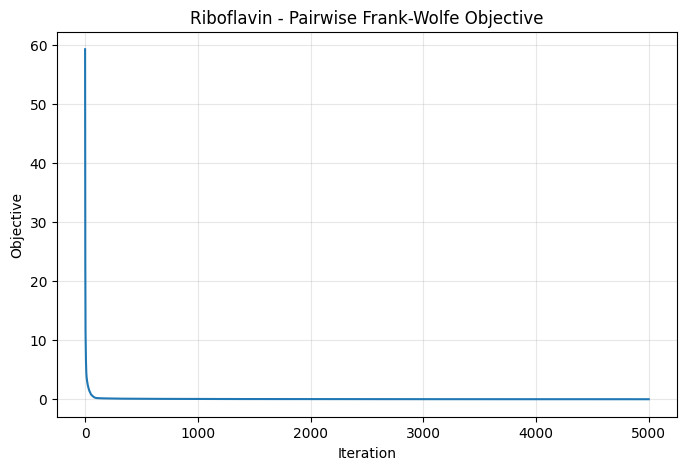

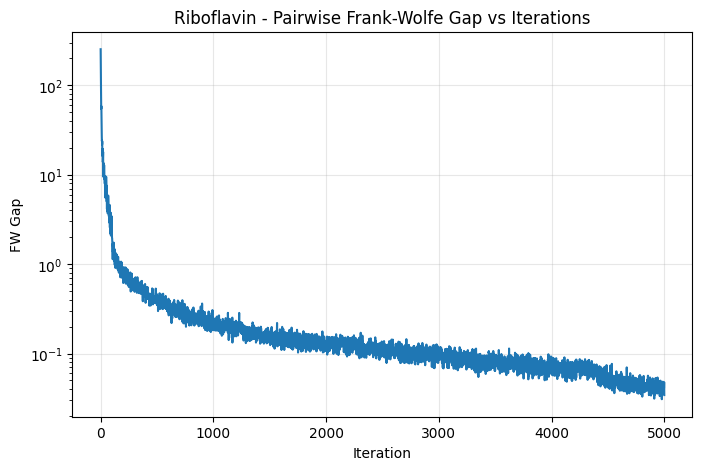

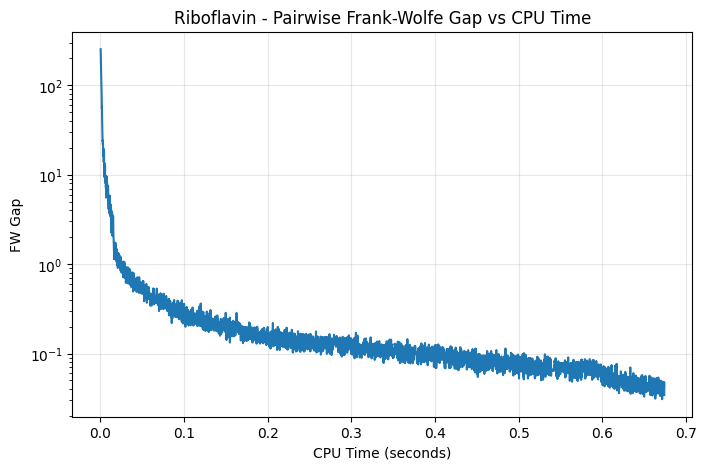

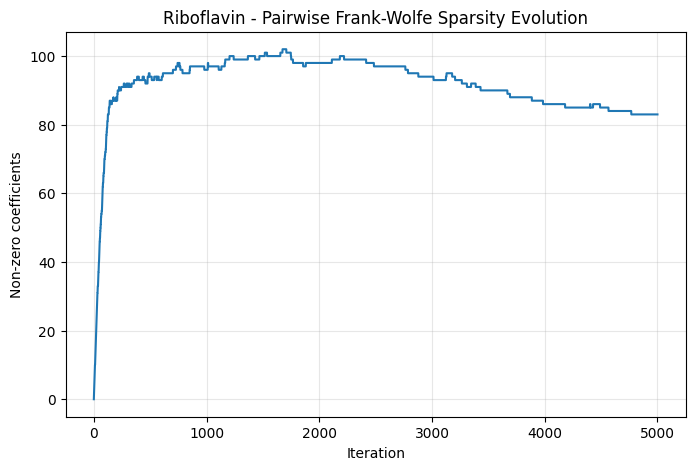

In [ ]:

# Riboflavin plots
plot_fw_objective(objective_r, "Riboflavin")
plot_fw_gap_iterations(gap_r, "Riboflavin")
plot_fw_gap_runtime(gap_r, runtime_hist_r, "Riboflavin")
plot_fw_sparsity(nonzero_r, "Riboflavin")


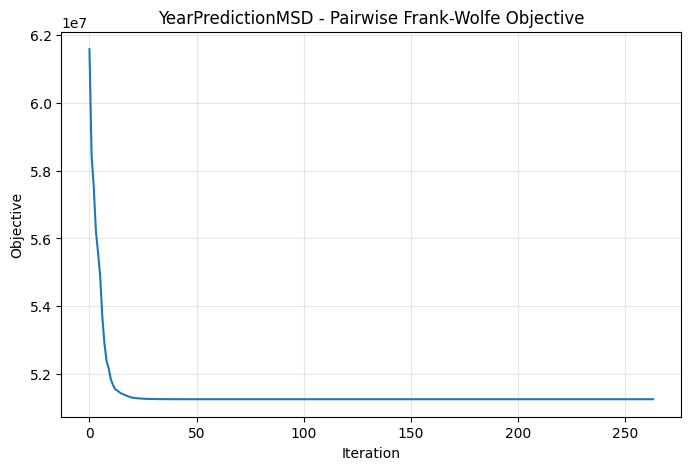

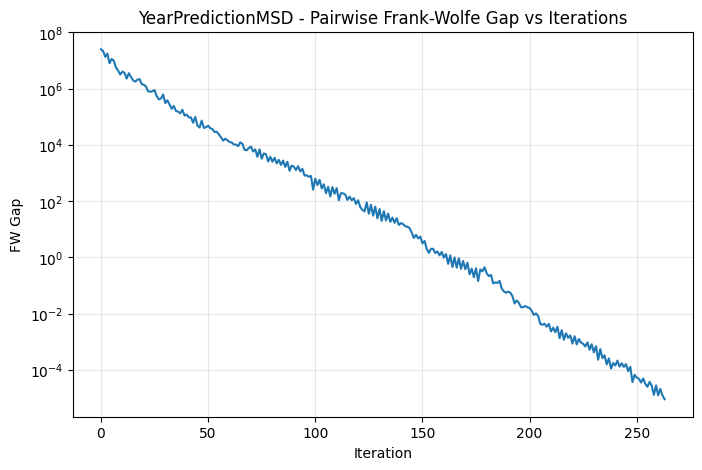

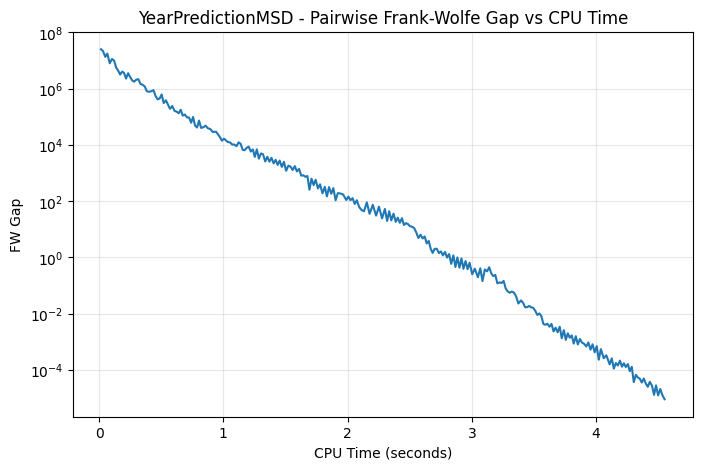

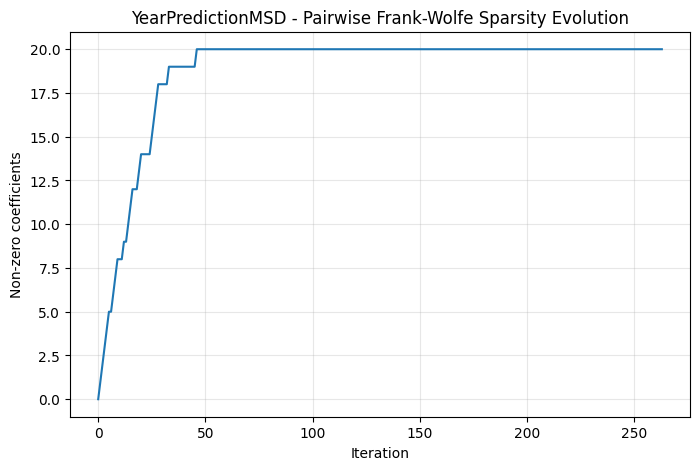

In [ ]:
# YearPredictionMSD plots
plot_fw_objective(objective_m, "YearPredictionMSD")
plot_fw_gap_iterations(gap_m, "YearPredictionMSD")
plot_fw_gap_runtime(gap_m, runtime_hist_m, "YearPredictionMSD")
plot_fw_sparsity(nonzero_m, "YearPredictionMSD")


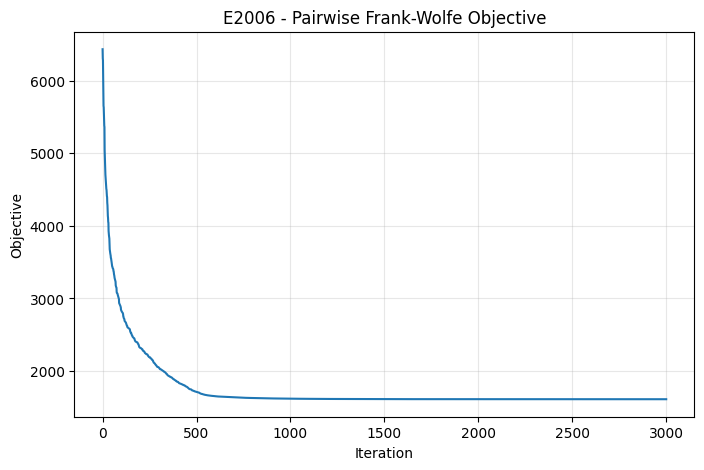

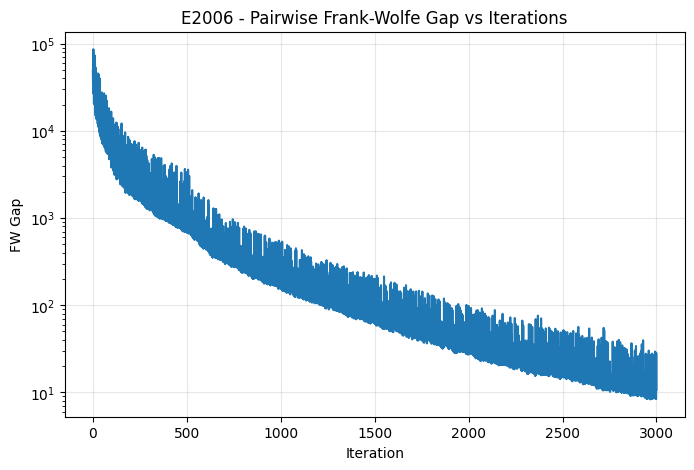

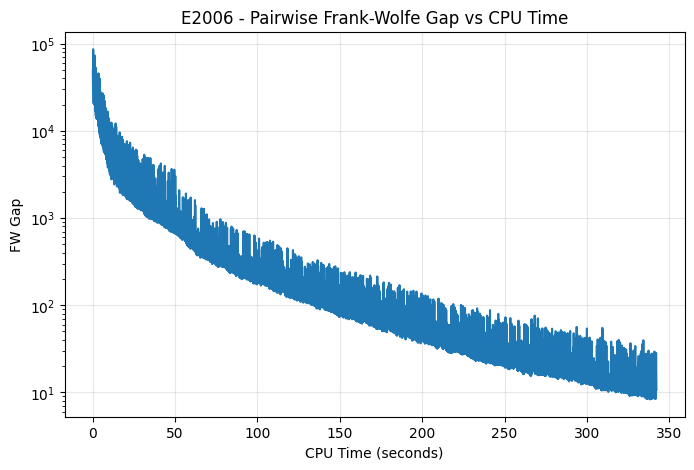

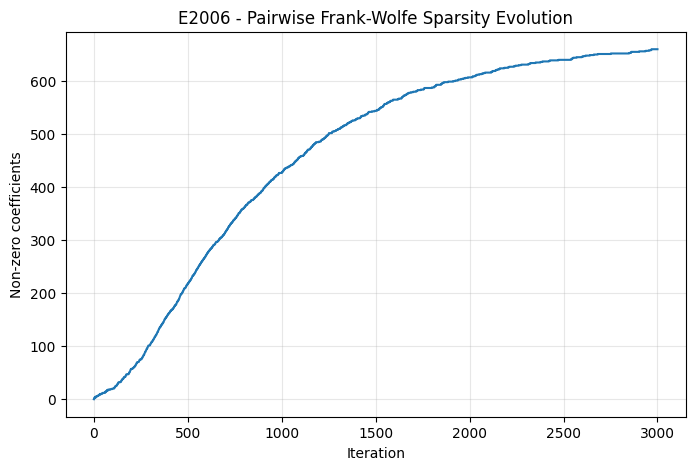

In [ ]:
# E2006 plots
plot_fw_objective(objective_e, "E2006")
plot_fw_gap_iterations(gap_e, "E2006")
plot_fw_gap_runtime(gap_e, runtime_hist_e, "E2006")
plot_fw_sparsity(nonzero_e, "E2006")


In [ ]:
# Pairwise Frank-Wolfe summary
pairwise_summary = pd.DataFrame({
    "Dataset": ["Riboflavin", "YearPredictionMSD", "E2006"],
    "Algorithm": "Pairwise Frank-Wolfe",
    "Tau": [tau_r, tau_m, tau_e],
    "Iterations": [len(objective_r) - 1, len(objective_m) - 1, len(objective_e) - 1],
    "Objective": [objective_r[-1], objective_m[-1], objective_e[-1]],
    "FW Gap": [gap_r[-1], gap_m[-1], gap_e[-1]],
    "Runtime": [runtime_r, runtime_m, runtime_e],
    "L1 Norm": [np.linalg.norm(x_r, 1), np.linalg.norm(x_m, 1), np.linalg.norm(x_e, 1)],
    "Non-zero": [nonzero_r[-1], nonzero_m[-1], nonzero_e[-1]],
})

display(pairwise_summary)


,Dataset,Algorithm,Tau,Iterations,Objective,FW Gap,Runtime,L1 Norm,Non-zero
0,Riboflavin,Pairwise Frank-Wolfe,3.0,5000,0.02622199532656096,0.03431929469711714,0.6742486020002616,3.0000000000000004,83
1,YearPredictionMSD,Pairwise Frank-Wolfe,10.0,263,51260896.55639085,9.041279554367065e-06,4.551759266999852,9.999999999999998,20
2,E2006,Pairwise Frank-Wolfe,3.0,3000,1611.9464917360895,10.669547275206469,342.23016227100015,3.0000000000000018,659


## Classic Frank-Wolfe — Erdem Altun


In [ ]:
## STEP 1 ##
# ============================================================
# Classic Frank-Wolfe Algorithm for Constrained LASSO Problem
# ============================================================

import time

# tolerance, max_iter and progress_every values are selected according to the dataset
def classic_fw(A, b, tau, tolerance, max_iter, progress_every):

    # creating empty lists for results
    objective_history = []
    gap_history = []
    alpha_history = []
    runtime_history = []
    nonzero_history = []

    p = A.shape[1]   # number of features
    x = np.zeros(p)

    start_time = time.perf_counter()

    for k in range(max_iter + 1):

        # calculation of residual
        r = A @ x - b

        # calculation of gradient
        g = 2 * (A.T @ r)

        # Linear Minimization Oracle: compute s_k
        j = np.argmax(np.abs(g))
        s = np.zeros(p)
        s[j] = -tau * np.sign(g[j])

        # Frank-Wolfe direction: d_k = s_k - x_k
        d = s - x

        # objective value: f(x_k) = ||Ax_k - b||^2
        objective = np.dot(r, r)

        # Frank-Wolfe gap
        gap = np.dot(x - s, g)

        # iteration results
        objective_history.append(objective)
        gap_history.append(gap)

        runtime_history.append(
            time.perf_counter() - start_time
        )

        nonzero_history.append(
            np.count_nonzero(np.abs(x) > 1e-8)
        )

        # show progress
        if k > 0 and k % progress_every == 0:
            print("Iteration:", k)
            print("Objective value:", objective)
            print("FW gap:", gap)
            print()

        # stopping criterion
        if gap <= tolerance:
            break

        if k == max_iter:
            break

        # exact line search
        # the papers define exact line search as minimizing the objective along the current Frank-Wolfe direction over [0, 1]

        # for our quadratic least-squares objective:
        # f(x + alpha*d) = ||A(x + alpha*d) - b||^2     = ||r + alpha*A*d||^2


        Ad = A @ d     # calculate A*d for the line search formula

        # ||A*d||^2 = (A*d)^T(A*d)
        # the square cancels the square root in the Euclidean norm
        denom = np.dot(Ad, Ad)

        # avoid division by a value very close to zero
        if denom <= 1e-15:
            break

        # because the objective is quadratic, the exact minimizer can be calculated directly
        # unconstrained minimizer: alpha = - <r, A*d> / ||A*d||^2
        # clip restricts alpha to the Frank-Wolfe feasible interval [0, 1]
        alpha = np.clip(-np.dot(r, Ad) / denom, 0.0, 1.0)


        alpha_history.append(alpha)   # store the step size for each iteration

        # update rule: x_new = x + alpha*d
        x = x + alpha * d

    # total run time
    end_time = time.perf_counter()
    runtime = end_time - start_time

    return (x, objective_history, gap_history, alpha_history, runtime, runtime_history, nonzero_history)

In [ ]:
## STEP 2 ##
# ============================================================
# Classic Frank-Wolfe for Riboflavin Dataset
# ============================================================

# select fixed tau value
tau_r = 3.0

x_r, objective_r, gap_r, alpha_r, runtime_r, runtime_hist_r, nonzero_r = classic_fw(
    X1, Y1,
    tau_r,
    tolerance=1e-5,
    max_iter=5000,
    progress_every=1000)

print("Final objective:", objective_r[-1])   # sum of squared residuals
print("Final FW gap:", gap_r[-1])
print("Iterations:", len(objective_r) - 1)
print("Runtime:", runtime_r)
print("L1 norm:", np.sum(np.abs(x_r)))    # did the Frank-Wolfe solution actually remain within the L1 ball?
print("Non-zero coefficients:", np.count_nonzero(np.abs(x_r) > 1e-8))  # count coefficients larger than 1e-8


Iteration: 1000
Objective value: 0.2224850290941349
FW gap: 0.5861306064200122

Iteration: 2000
Objective value: 0.13777531406537416
FW gap: 0.29361253070356796

Iteration: 3000
Objective value: 0.10578542463552561
FW gap: 0.21600964007412737

Iteration: 4000
Objective value: 0.08878290332596839
FW gap: 0.17386026048780567

Iteration: 5000
Objective value: 0.07802547465065938
FW gap: 0.14238447668855414

Final objective: 0.07802547465065938
Final FW gap: 0.14238447668855414
Iterations: 5000
Runtime: 1.0649492739999005
L1 norm: 2.9035580541416817
Non-zero coefficients: 104


In [ ]:
## STEP 3 ##
# ============================================================
# Classic Frank-Wolfe for YearPredictionMSD Dataset
# ============================================================

# select fixed tau value
tau_m = 10.0

x_m, objective_m, gap_m, alpha_m, runtime_m, runtime_hist_m, nonzero_m = classic_fw(
    X2, Y2,
    tau_m,
    tolerance=1e-5,
    max_iter=3000,
    progress_every=500)

print("Final objective:", objective_m[-1])  # sum of squared residuals
print("Final FW gap:", gap_m[-1])
print("Iterations:", len(objective_m) - 1)
print("Runtime:", runtime_m)
print("L1 norm:", np.sum(np.abs(x_m)))    # check L1 constraint
print("Non-zero coefficients:", np.count_nonzero(np.abs(x_m) > 1e-8))  # count coefficients larger than 1e-8

Iteration: 500
Objective value: 51347098.79414898
FW gap: 169812.18638888188

Iteration: 1000
Objective value: 51305651.21579293
FW gap: 61638.28292148829

Iteration: 1500
Objective value: 51291133.52105158
FW gap: 47405.512948682386

Iteration: 2000
Objective value: 51283757.16919995
FW gap: 57459.621450610364

Iteration: 2500
Objective value: 51279282.52968361
FW gap: 32203.480900651866

Iteration: 3000
Objective value: 51276273.3303806
FW gap: 24214.56919964838

Final objective: 51276273.3303806
Final FW gap: 24214.56919964838
Iterations: 3000
Runtime: 152.10552467299976
L1 norm: 9.970672786711894
Non-zero coefficients: 20


In [ ]:
## STEP 4 ##

# ============================================================
# Classic Frank-Wolfe for E2006 Dataset
# ============================================================

# select fixed tau value
tau_e = 3.0

x_e, objective_e, gap_e, alpha_e, runtime_e, runtime_hist_e, nonzero_e = classic_fw(
    X3, Y3,
    tau_e,
    tolerance=1e-5,
    max_iter=3000,
    progress_every=500
)

print("Final objective:", objective_e[-1])  # sum of squared residuals
print("Final FW gap:", gap_e[-1])
print("Iterations:", len(objective_e) - 1)
print("Runtime:", runtime_e)
print("L1 norm:", np.sum(np.abs(x_e)))  # check L1 constraint
print("Non-zero coefficients:", np.count_nonzero(np.abs(x_e) > 1e-8))  # count active coefficients

Iteration: 500
Objective value: 2032.4980171800703
FW gap: 2963.1206115431437

Iteration: 1000
Objective value: 1875.4954399110652
FW gap: 583.50722990874

Iteration: 1500
Objective value: 1812.5303484242954
FW gap: 1188.1579672806447

Iteration: 2000
Objective value: 1776.7319555355139
FW gap: 905.0626165548368

Iteration: 2500
Objective value: 1751.9144341496426
FW gap: 578.6803016175597

Iteration: 3000
Objective value: 1734.2318037312084
FW gap: 225.71802031507445

Final objective: 1734.2318037312084
Final FW gap: 225.71802031507445
Iterations: 3000
Runtime: 275.1054881260002
L1 norm: 2.6092318814460636
Non-zero coefficients: 380


In [ ]:
## STEP 5 ##

# ============================================================
# Classic Frank-Wolfe Plot Functions
# ============================================================

import matplotlib.pyplot as plt
def plot_fw_objective(objective_history, dataset_name):   # plot the objective value over the iterations

    iterations = np.arange(len(objective_history))   # create iteration numbers from the objective history

    plt.figure(figsize=(8, 5))   # width 8 and height 5
    plt.plot(iterations,objective_history)

    plt.xlabel("Iteration")
    plt.ylabel("Objective")
    plt.title(dataset_name + " - Classic Frank-Wolfe Objective")

    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
def plot_fw_gap_iterations(gap_history, dataset_name):  # plot the Frank-Wolfe gap over the iterations

    gap_history = np.asarray(gap_history)      # convert history to numpy array for filtering
    iterations = np.arange(len(gap_history))

    positive = gap_history > 0     # keep only positive gap values for logarithmic scale

    plt.figure(figsize=(8, 5))

    # semilogy uses a linear x-axis and logarithmic y-axis
    plt.semilogy(iterations[positive], gap_history[positive])    # use logarithmic scale to better visualize gap reduction

    plt.xlabel("Iteration")
    plt.ylabel("FW Gap")

    plt.title(dataset_name + " - Classic Frank-Wolfe Gap vs Iterations")

    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
def plot_fw_gap_runtime(gap_history, runtime_history, dataset_name):   # plot the Frank-Wolfe gap against computational time

    gap_history = np.asarray(gap_history)
    runtime_history = np.asarray(runtime_history)

    positive = gap_history > 0        # keep only positive gap values for logarithmic scale

    plt.figure(figsize=(8, 5))

    plt.semilogy(runtime_history[positive], gap_history[positive])    # compare convergence with cumulative CPU time

    plt.xlabel("CPU Time (seconds)")
    plt.ylabel("FW Gap")

    plt.title(dataset_name + " - Classic Frank-Wolfe Gap vs CPU Time")

    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
def plot_fw_sparsity(nonzero_history, dataset_name):   # plot the number of active coefficients during the iterations

    iterations = np.arange(len(nonzero_history))

    plt.figure(figsize=(8, 5))

    plt.plot(iterations, nonzero_history)    # track the evolution of non-zero coefficients

    plt.xlabel("Iteration")
    plt.ylabel("Non-zero coefficients")

    plt.title( dataset_name + " - Classic Frank-Wolfe Sparsity Evolution")   # graph title

    plt.grid(alpha=0.3)

    plt.show()

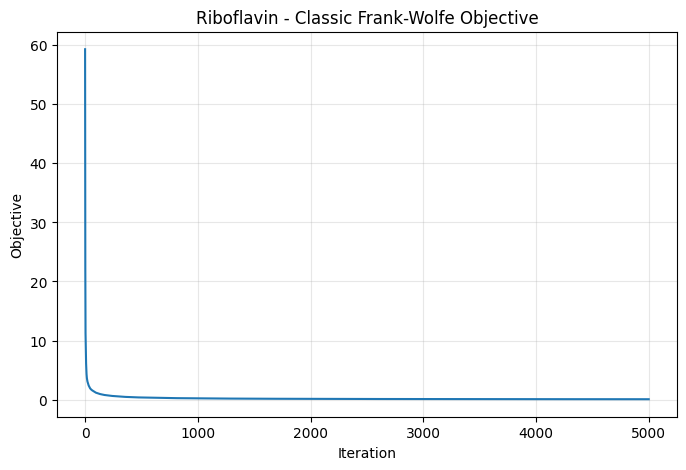

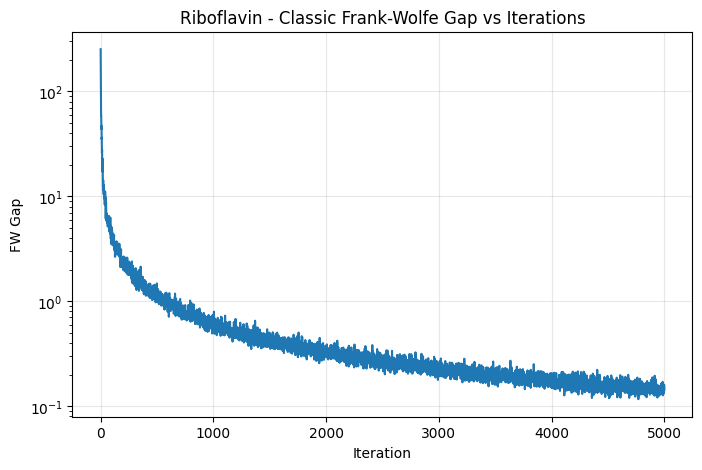

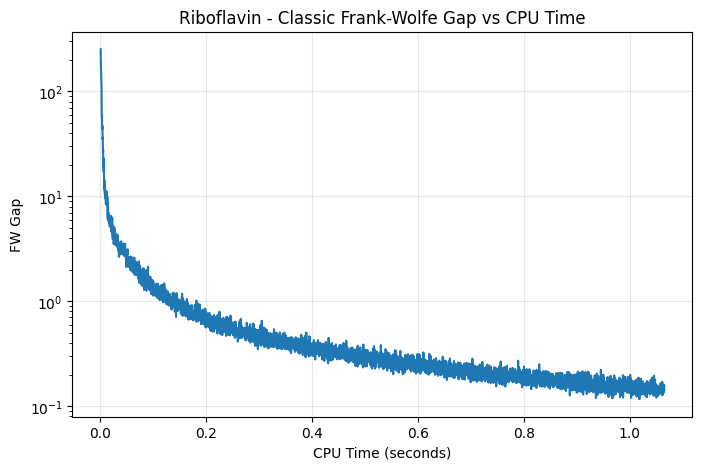

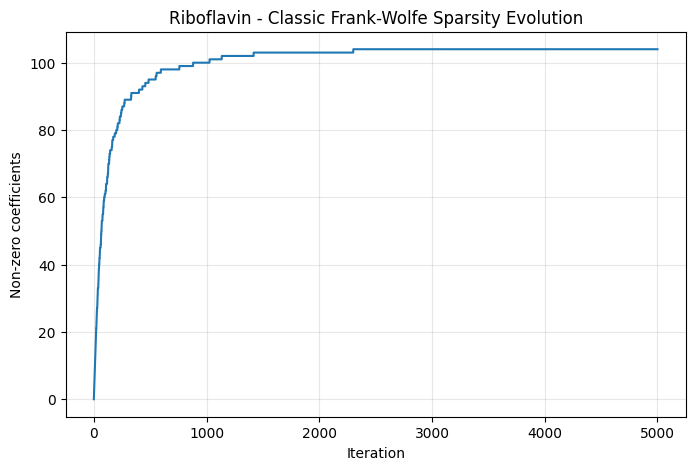

In [ ]:
## STEP 6 ##


# ============================================================
# Riboflavin - Classic Frank-Wolfe Plots
# ============================================================

plot_fw_objective(objective_r, "Riboflavin")   # objective convergence

plot_fw_gap_iterations(gap_r, "Riboflavin")    # FW gap convergence by iteration

plot_fw_gap_runtime(gap_r,runtime_hist_r, "Riboflavin")   # FW gap convergence by CPU time

plot_fw_sparsity(nonzero_r, "Riboflavin")   # evolution of the number of active coefficients


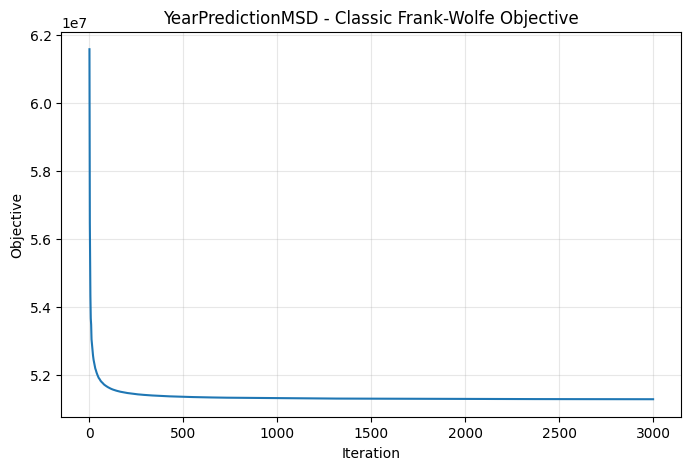

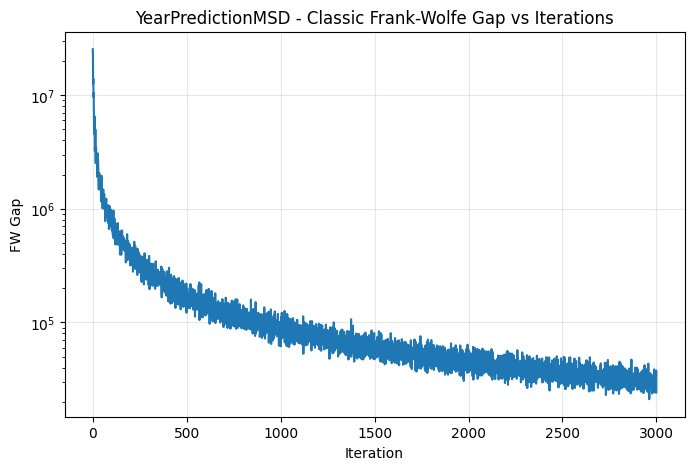

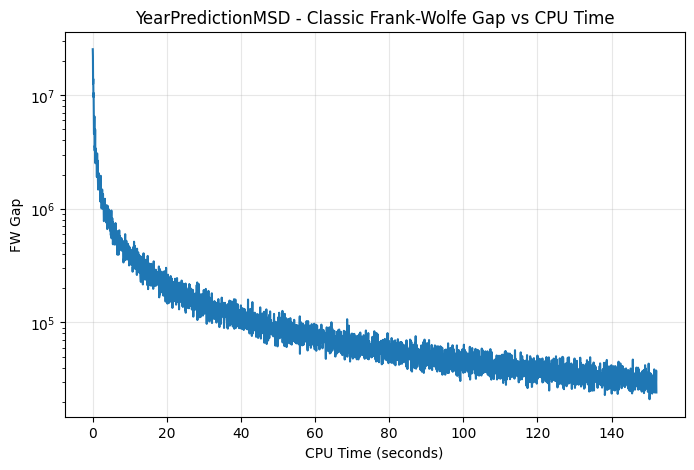

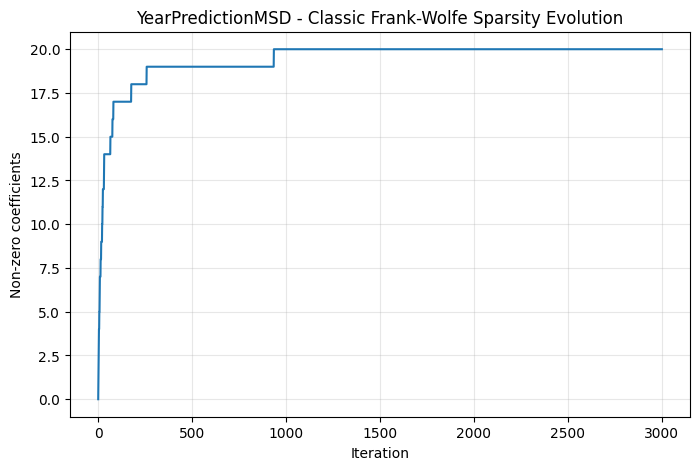

In [ ]:
## STEP 7 ##


# ============================================================
# YearPredictionMSD - Classic Frank-Wolfe Plots
# ============================================================

plot_fw_objective(objective_m, "YearPredictionMSD")  # objective convergence

plot_fw_gap_iterations(gap_m, "YearPredictionMSD")   # FW gap convergence by iteration

plot_fw_gap_runtime(gap_m, runtime_hist_m,"YearPredictionMSD")    # FW gap convergence by CPU time

plot_fw_sparsity(nonzero_m, "YearPredictionMSD")    # evolution of the number of active coefficients


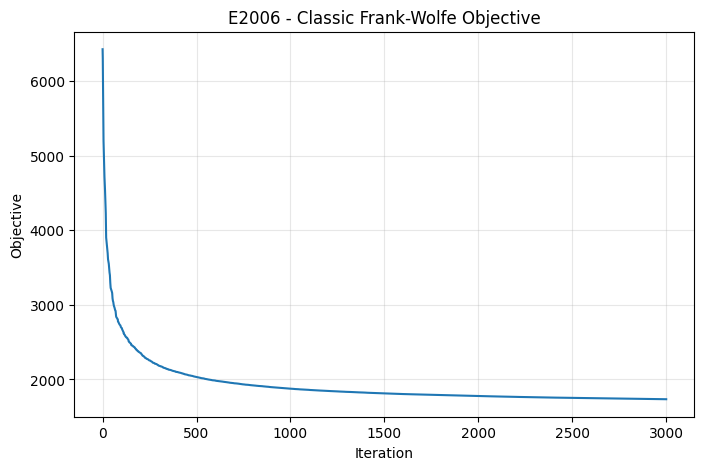

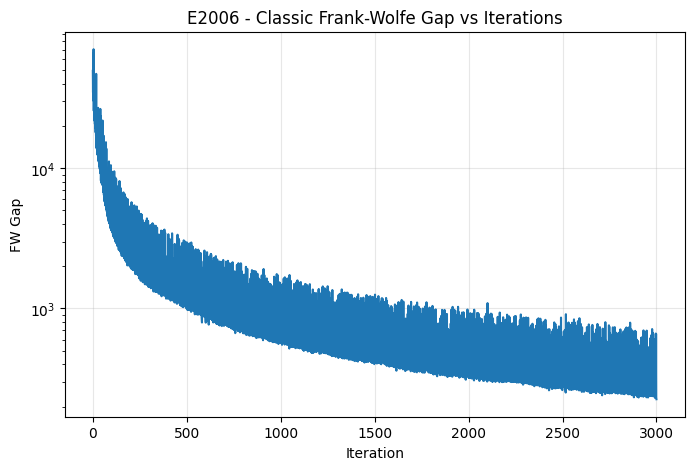

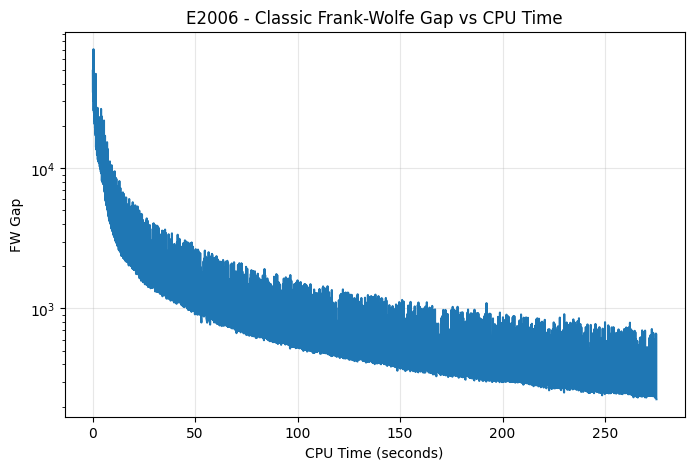

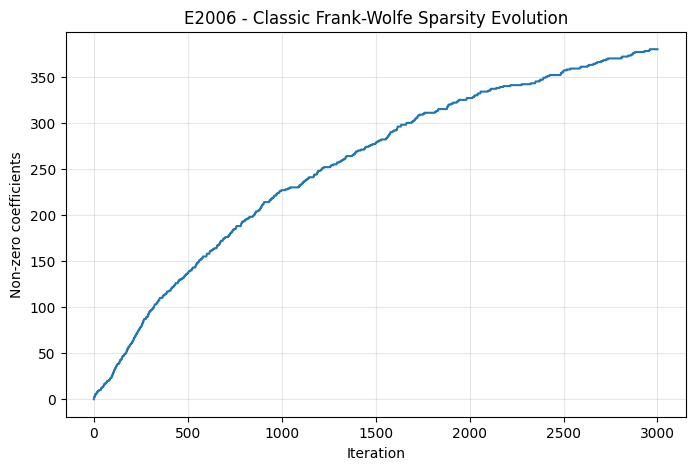

In [ ]:
## STEP 8 ##

# ============================================================
# E2006 - Classic Frank-Wolfe Plots
# ============================================================

plot_fw_objective(objective_e, "E2006")    # objective convergence

plot_fw_gap_iterations(gap_e, "E2006")     # FW gap convergence by iteration

plot_fw_gap_runtime(gap_e, runtime_hist_e, "E2006")   # FW gap convergence by CPU time

plot_fw_sparsity(nonzero_e, "E2006")   # evolution of the number of active coefficients


In [ ]:
## STEP 9 ##

# ============================================================
# Classic Frank Wolfe Comparison Table
# ============================================================

pd.set_option("display.float_format", str)   # show float values directly instead of scientific notation
fw_summary = pd.DataFrame([                  # create one summary table for the final results of all three datasets
    {
        "Dataset": "Riboflavin",
        "Algorithm": "Classic Frank-Wolfe",
        "Tau": tau_r,
        "Iterations": len(objective_r) - 1,
        "Objective": objective_r[-1],
        "FW Gap": gap_r[-1],
        "Runtime": runtime_r,
        "L1 Norm": np.sum(np.abs(x_r)),
        "Non-zero": np.count_nonzero(np.abs(x_r) > 1e-8)},

    {
        "Dataset": "YearPredictionMSD",
        "Algorithm": "Classic Frank-Wolfe",
        "Tau": tau_m,
        "Iterations": len(objective_m) - 1,
        "Objective": objective_m[-1],
        "FW Gap": gap_m[-1],
        "Runtime": runtime_m,
        "L1 Norm": np.sum(np.abs(x_m)),
        "Non-zero": np.count_nonzero(np.abs(x_m) > 1e-8)},
    {
        "Dataset": "E2006",
        "Algorithm": "Classic Frank-Wolfe",
        "Tau": tau_e,
        "Iterations": len(objective_e) - 1,
        "Objective": objective_e[-1],
        "FW Gap": gap_e[-1],
        "Runtime": runtime_e,
        "L1 Norm": np.sum(np.abs(x_e)),
        "Non-zero": np.count_nonzero(np.abs(x_e) > 1e-8)}
])

display(fw_summary)  # display the final comparison table

,Dataset,Algorithm,Tau,Iterations,Objective,FW Gap,Runtime,L1 Norm,Non-zero
0,Riboflavin,Classic Frank-Wolfe,3.0,5000,0.07802547465065938,0.14238447668855414,1.0649492739999005,2.9035580541416817,104
1,YearPredictionMSD,Classic Frank-Wolfe,10.0,3000,51276273.3303806,24214.56919964838,152.10552467299976,9.970672786711894,20
2,E2006,Classic Frank-Wolfe,3.0,3000,1734.2318037312084,225.71802031507445,275.1054881260002,2.6092318814460636,380


## Projected Gradient — Andela Ruta Stancu


In [ ]:
import os, time, zipfile, bz2, ssl
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml, load_svmlight_file
from sklearn.preprocessing import StandardScaler

# 1. Force OS-level SSL bypass for sklearn's fetch_openml
os.environ['PYTHONHTTPSVERIFY'] = '0'
ssl._create_default_https_context = ssl._create_unverified_context

# =====================================================================
# 1. LOAD DATASETS (Forced OS-Level Bypass)
# =====================================================================

# --- Riboflavin ---
print("Loading Riboflavin...")
data1 = fetch_openml(name='riboflavin', version=1, parser='auto')
X1 = np.array(data1.data, dtype=np.float64)
Y1 = np.array(data1.target, dtype=np.float64)

scaler1 = StandardScaler()
X1 = scaler1.fit_transform(X1)
Y1 = Y1 - np.mean(Y1)

# --- YearPredictionMSD ---
print("Loading YearPredictionMSD...")
if not os.path.exists("YearPredictionMSD.txt"):
    # Use Colab's native wget to bypass Python's SSL checks entirely
    !wget --no-check-certificate -O temp.zip "https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip"
    with zipfile.ZipFile("temp.zip", 'r') as z:
        z.extractall(".")
    os.remove("temp.zip")

df_msd = pd.read_csv("YearPredictionMSD.txt", header=None)
Y2 = df_msd.iloc[:, 0].values.astype(np.float64)
X2 = df_msd.iloc[:, 1:].values.astype(np.float64)

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2)
Y2 = Y2 - np.mean(Y2)

# --- E2006-tfidf ---
print("Loading E2006-tfidf...")
if not os.path.exists("E2006.train"):
    !wget --no-check-certificate -O temp.bz2 "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/regression/E2006.train.bz2"
    with bz2.BZ2File("temp.bz2", 'rb') as f, open("E2006.train", 'wb') as out_file:
        out_file.write(f.read())
    os.remove("temp.bz2")

X3, Y3 = load_svmlight_file("E2006.train")
scaler3 = StandardScaler(with_mean=False)
X3 = scaler3.fit_transform(X3)
Y3 = Y3 - np.mean(Y3)

print("Data successfully loaded.")

Loading Riboflavin...
Loading YearPredictionMSD...
Loading E2006-tfidf...
Data successfully loaded.


In [ ]:
X1, Y1
X2, Y2
X3, Y3

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 19971015 stored elements and shape (16087, 150360)>,
 array([-0.07538649, -0.01258503, -0.17582682, ...,  0.05571381,
        -0.24869247, -0.11322335]))

In [ ]:
# ============================================================
# PROJECTED GRADIENT - EXPERIMENT SETTINGS
# ============================================================

# Common stopping tolerance:
#
# Stop when:
#
#       FW gap <= 10^(-5)
#
# max_iter is only the maximum safety budget.

PG_CONFIG = {

    "Riboflavin": {
        "X": X1,
        "Y": Y1,
        "tau": 3.0,
        "max_iter": 5000,
        "tol": 1e-5
    },

    "YearPredictionMSD": {
        "X": X2,
        "y": Y2,
        "tau": 10.0,
        "max_iter": 3000,
        "tol": 1e-5
    },

    "E2006": {
        "X": X3,
        "y": Y3,
        "tau": 3.0,
        "max_iter": 1000,
        "tol": 1e-5
    }
}

In [ ]:
# ============================================================
# LASSO OBJECTIVE
# ============================================================

def lasso_objective(A, b, x):
    """
    Constrained LASSO objective:

        f(x) = ||Ax - b||_2^2
    """

    residual = A @ x - b

    residual = np.asarray(
        residual
    ).reshape(-1)

    return float(
        residual @ residual
    )

In [ ]:
# ============================================================
# LASSO GRADIENT
# ============================================================

def lasso_gradient(A, b, x):
    """
    Gradient of:

        f(x) = ||Ax-b||_2^2

    Formula:

        grad f(x) = 2 A^T(Ax-b)
    """

    residual = A @ x - b
    residual = np.asarray(residual).reshape(-1)

    grad = 2.0 * (A.T @ residual)

    return np.asarray(grad).reshape(-1)

In [ ]:
# ============================================================
# EUCLIDEAN PROJECTION ONTO THE L1 BALL
# ============================================================

def project_l1_ball(v, tau):
    """
    Projection onto:

        C = {x : ||x||_1 <= tau}

    Solves:

        min_z  1/2 ||z-v||_2^2
        s.t.   ||z||_1 <= tau

    Projected coordinates:

        z_i = sign(v_i) * max(|v_i| - theta, 0)
    """

    v = np.asarray(v, dtype=float).reshape(-1)

    if tau < 0:
        raise ValueError("tau must be non-negative")

    # Already feasible
    if np.linalg.norm(v, 1) <= tau:
        return v.copy()

    if tau == 0:
        return np.zeros_like(v)

    # Sort |v_i| from largest to smallest
    u = np.sort(np.abs(v))[::-1]

    cumulative_sum = np.cumsum(u)

    j = np.arange(1, len(v) + 1)

    condition = (
        u - (cumulative_sum - tau) / j > 0
    )

    rho = np.nonzero(condition)[0][-1]

    # Projection threshold
    theta = (
        cumulative_sum[rho] - tau
    ) / (rho + 1)

    # z_i = sign(v_i) max(|v_i|-theta, 0)
    projected = (
        np.sign(v)
        *
        np.maximum(
            np.abs(v) - theta,
            0.0
        )
    )

    return projected

In [ ]:
# ============================================================
# COMMON FW GAP / OPTIMALITY CERTIFICATE
# ============================================================

def fw_gap_l1(x, grad, tau):
    """
    FW gap:

        G(x) = <grad, x-s>

    For the L1 ball:

        j = argmax_i |grad_i|

        s_j = -tau sign(grad_j)

    Therefore:

        G(x)
        = grad^T x + tau ||grad||_infinity
    """

    gap = (
        np.dot(grad, x)
        +
        tau * np.max(np.abs(grad))
    )

    # Numerical floating-point protection
    return max(float(gap), 0.0)

In [ ]:
# ============================================================
# ESTIMATE SPECTRAL NORM OF A
# ============================================================

def estimate_spectral_norm(
    A,
    n_power_iterations=20,
    random_state=42
):
    """
    Approximate ||A||_2 using power iteration.

    This avoids computing a complete SVD,
    especially important for E2006.
    """

    rng = np.random.default_rng(
        random_state
    )

    n_features = A.shape[1]

    # Random initial vector
    v = rng.standard_normal(
        n_features
    )

    v = v / np.linalg.norm(v)

    for _ in range(
        n_power_iterations
    ):

        Av = A @ v

        AtAv = (
            A.T @ Av
        )

        AtAv = np.asarray(
            AtAv
        ).reshape(-1)

        norm_AtAv = np.linalg.norm(
            AtAv
        )

        if norm_AtAv == 0:

            return 0.0

        v = (
            AtAv
            /
            norm_AtAv
        )

    sigma = np.linalg.norm(
        np.asarray(
            A @ v
        ).reshape(-1)
    )

    return float(sigma)

In [ ]:
# ============================================================
# PROJECTED GRADIENT FOR CONSTRAINED LASSO
# ============================================================

def projected_gradient_lasso(
    A,
    b,
    tau,
    max_iter,
    tol=1e-5,
    power_iterations=20,
    verbose=True
):

    """
    Solve:

        min_x  f(x) = ||Ax-b||_2^2
        s.t.   ||x||_1 <= tau


    PROJECTED GRADIENT PIPELINE
    ---------------------------
    Stopping rule
    -------------

        G(x_k) <= tol

    where G(x_k) is the Frank-Wolfe gap.

    max_iter is used only as a maximum iteration budget.

    1. Gradient:

        g_k = 2 A^T(Ax_k-b)

    2. Gradient step:

        y_k = x_k - eta*g_k

    3. Projection:

        z_k = Pi_C(y_k)

    4. Projected-gradient direction:

        d_k = z_k - x_k

    5. Projected-gradient mapping:

        PG_eta(x_k) = (x_k-z_k)/eta

    6. Exact line search:

        gamma_k =
        argmin_{gamma in [0,1]}
        f(x_k + gamma*d_k)

    For our quadratic objective:

                    -g_k^T d_k
        gamma_k = -----------------
                    2 ||A d_k||^2

    7. Update:

        x_(k+1) = (1-gamma_k)x_k + gamma_k*z_k

    Because both x_k and z_k are feasible and
    gamma_k is in [0,1], x_(k+1) remains feasible.
    """

    b = np.asarray( b, dtype=float ).reshape(-1)

    n_features = A.shape[1]

    #START TOTAL RUNTIME
    # The timer starts BEFORE spectral-norm estimation.
    #
    # Runtime includes:spectral norm estimation + optimization iterations

    # Total algorithm runtime
    start_time = time.perf_counter()

    # ========================================================
    # INITIAL POINT
    # ========================================================

    # x0 = 0
    #
    # ||x0||_1 = 0 <= tau
    #
    # therefore x0 is feasible.

    x = np.zeros( n_features, dtype=float)

    # At x_0=0, r0 = Ax0-b = -b
    residual = -b.copy()
    # ========================================================
    # ESTIMATE SPECTRAL NORM
    # ========================================================

    if verbose:

        print("Estimating spectral norm...")

    sigma = estimate_spectral_norm( A, n_power_iterations=power_iterations)

    if sigma == 0:

        raise ValueError( "Spectral norm is zero.")

    # ========================================================
    # LIPSCHITZ CONSTANT
    # ========================================================

    if verbose:
        print("Estimating spectral norm...")

    sigma = estimate_spectral_norm( A, n_power_iterations=power_iterations)

    if sigma == 0:
        raise ValueError( "Spectral norm is zero.")

    # L = 2 ||A||_2^2
    L = 2.0 * sigma**2

    # eta = 1/L
    eta = 1.0 / L

    if verbose:

        print(
            f"Estimated ||A||_2 = {sigma:.6f}"
        )

        print(
            f"Lipschitz constant L = {L:.6f}"
        )

        print(
            f"Gradient step eta = {eta:.8e}"
        )

    # ========================================================
    # HISTORY
    # ========================================================

    history = {

        "iteration": [],
        "objective": [],
        "fw_gap": [],
        "pg_norm": [],
        "runtime": [],
        "l1_norm": [],
        "feasibility_violation": [],
        "nonzero": [],
        "line_search_gamma": []
    }

    # ========================================================
    # STOPPING INFORMATION
    # ========================================================

    iterations_run = 0
    converged = False
    stop_reason = "maximum iterations reached"


    # ========================================================
    # MAIN LOOP
    # ========================================================

    for k in range(max_iter):

        # ----------------------------------------------------
        # 1. GRADIENT
        #
        # g_k = 2 A^T(Ax_k-b)
        # ----------------------------------------------------

        grad = ( 2.0 * np.asarray( A.T @ residual).reshape(-1))

        # ----------------------------------------------------
        # 2. OBJECTIVE
        #
        # f(x_k) = ||Ax_k-b||_2^2
        # ----------------------------------------------------

        f_value = float( residual @ residual)

        # ----------------------------------------------------
        # 3. FW GAP
        # ----------------------------------------------------

        gap = fw_gap_l1( x,grad, tau)

        # ====================================================
        # 4. GRADIENT STEP
        #
        # y_k = x_k - eta*g_k
        # ====================================================

        y = x - eta * grad

        # ====================================================
        # 5. PROJECTION
        #
        # z_k = Pi_C(y_k)
        #
        # Therefore:
        #
        # ||z_k||_1 <= tau
        # ====================================================

        z = project_l1_ball( y, tau)

        # ====================================================
        # 6. PROJECTED-GRADIENT DIRECTION
        #
        # d_k = z_k - x_k
        # ====================================================

        d = z - x

        # ====================================================
        # 7. PROJECTED-GRADIENT MAPPING
        #
        # PG_eta(x_k) = (x_k-z_k)/eta
        #
        # ||PG_eta(x_k)|| -> 0
        # means approaching stationarity.
        # ====================================================

        pg_norm = ( np.linalg.norm(d) / eta)

        # ----------------------------------------------------
        # RECORD CURRENT STATISTICS
        # ----------------------------------------------------

        current_l1 = float( np.linalg.norm(x, 1))

        history["iteration"].append(k)

        history["objective"].append(
            f_value
        )

        history["fw_gap"].append(
            gap
        )

        history["pg_norm"].append(
            pg_norm
        )

        history["runtime"].append(
            time.perf_counter()
            -
            start_time
        )

        history["l1_norm"].append(
            current_l1
        )

        history[ "feasibility_violation"].append( max(current_l1 - tau, 0.0))

        history["nonzero"].append( np.count_nonzero( np.abs(x) > 1e-8))

        # ====================================================
        # TOLERANCE-BASED EARLY STOPPING
        # Stop if: G(x_k) <= 10^-5
        # ====================================================

        if gap <= tol:

            converged = True

            iterations_run = k

            stop_reason = ( "FW-gap tolerance reached")

            history[ "line_search_gamma"].append( np.nan)

            if verbose:

                print(
                    f"Converged at iteration {k}"
                    f" | gap = {gap:.3e}"
                    f" <= tolerance = {tol:.1e}" )

            break

        # ====================================================
        # 8. EXACT LINE SEARCH
        # ====================================================

        # phi(gamma) = f(x_k + gamma*d_k)

        Ad = np.asarray( A @ d ).reshape(-1)

        # denominator = 2 ||Ad||_2^2

        denominator = ( 2.0 * float(Ad @ Ad))

        # numerator = -g_k^T d_k

        numerator = ( -float(grad @ d))

        if denominator <= 1e-30:

            gamma = 0.0

        else:

            gamma = (numerator / denominator)

            # Exact line search restricted to gamma in [0,1]

            gamma = float( np.clip( gamma, 0.0, 1.0 ))

        history["line_search_gamma"].append(gamma)

        # ====================================================
        # 9. UPDATE
        #
        # x_(k+1)=(1-gamma)x_k + gamma*z_k
        #
        # Both x_k and z_k are feasible.
        #
        # Therefore x_(k+1) is feasible because the L1 ball is convex.
        # ====================================================

        x_new = ( (1.0 - gamma) * x + gamma * z  )

        # ====================================================
        # NUMERICAL FEASIBILITY SAFEGUARD
        # ====================================================

        # IN mathematical terms:
        #
        # ||x_new||_1 <= tau
        #
        # The following only protects against floating-point numerical errors.

        if np.linalg.norm(x_new, 1) > tau:

            x_new = project_l1_ball( x_new, tau)

            # Because the point was corrected, recompute residual exactly.

            residual = ( np.asarray( A @ x_new).reshape(-1)- b)

        else:

            # Efficient residual update:r_(k+1)=r_k + gamma A d_k

            residual = (residual + gamma * Ad )

        x = x_new
        iterations_run = k + 1

        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        if (verbose and
            ( k == 0 or (k + 1) % 500 == 0)):

            print(
                f"Iteration {k + 1}/{max_iter}"
                f" | objective = {f_value:.6f}"
                f" | gap = {gap:.6f}"
                f" | ||x||1 = "
                f"{np.linalg.norm(x,1):.6f}"
            )

    # ========================================================
    # FINAL FEASIBILITY CHECK
    # ========================================================

    # Final solution explicitly satisfy ||x||_1 <= tau.

    if np.linalg.norm(x, 1) > tau:

        x = project_l1_ball( x, tau)

        residual = ( np.asarray(A @ x ).reshape(-1) - b)

    # ========================================================
    # FINAL RESULTS
    # ========================================================

    final_grad = (2.0 * np.asarray(A.T @ residual).reshape(-1))

    final_objective = float(residual @ residual)

    final_gap = fw_gap_l1(x, final_grad, tau)

    # If tolerance is reached exactly after the last allowed update,
    # recognize convergence here.

    if final_gap <= tol:

        converged = True
        stop_reason = ( "FW-gap tolerance reached")

    runtime = (time.perf_counter() - start_time)

    final_l1 = float(np.linalg.norm(x, 1))

    final_nonzero = int( np.count_nonzero(np.abs(x) > 1e-8))

    # Final projected-gradient point
    final_z = project_l1_ball(x - eta * final_grad, tau)

    final_pg_norm = float(np.linalg.norm(final_z - x) / eta)

    feasibility_violation = max(final_l1 - tau, 0.0)

    # --------------------------------------------------------
    # Add final point to history
    # Only needed when the algorithm reached max_iter.
    #
    # If early stopping happened, the final iterate
    # was already recorded before break.
    # ========================================================

    if not (
        len(history["iteration"]) > 0
        and
        history["iteration"][-1]
        == iterations_run
    ):

        history[
            "iteration"
        ].append(
            iterations_run
        )

    history["objective"].append(
        final_objective
    )

    history["fw_gap"].append(
        final_gap
    )

    history["pg_norm"].append(
        final_pg_norm
    )

    history["runtime"].append(
        runtime
    )

    history["l1_norm"].append(
        final_l1
    )

    history[
        "feasibility_violation"
    ].append(
        feasibility_violation
    )

    history["nonzero"].append(
        final_nonzero
    )

    history[
        "line_search_gamma"
    ].append(
        np.nan
    )

    history = pd.DataFrame(
        history
    )

    return {

        "x": x,

        "objective":
            final_objective,

        "fw_gap":
            final_gap,

        "pg_norm":
            final_pg_norm,

        "iterations":
            max_iter,

        "runtime":
            runtime,

        "l1_norm":
            final_l1,

        "feasibility_violation":
            feasibility_violation,

        "feasible":
            final_l1 <= tau + 1e-10,

        "tau":
            tau,
        "tol": tol,

        "converged": converged,

        "stop_reason": stop_reason,

        "nonzero":
            final_nonzero,

        "sigma":
            sigma,

        "L":
            L,

        "eta":
            eta,

        "history":
            history
    }

In [ ]:
# ============================================================
# RIBOFLAVIN - PROJECTED GRADIENT
# ============================================================

pg_riboflavin = projected_gradient_lasso(

    A=X1,

    b=Y1,

    tau=3.0,

    max_iter=5000,

    tol=1e-5,

    verbose=True
)

Estimating spectral norm...
Estimating spectral norm...
Estimated ||A||_2 = 325.060661
Lipschitz constant L = 211328.866835
Gradient step eta = 4.73196121e-06
Iteration 1/5000 | objective = 59.302830 | gap = 252.795322 | ||x||1 = 0.362163
Iteration 500/5000 | objective = 2.041796 | gap = 9.707328 | ||x||1 = 3.000000
Iteration 1000/5000 | objective = 1.299205 | gap = 6.571049 | ||x||1 = 3.000000
Iteration 1500/5000 | objective = 0.983655 | gap = 5.162280 | ||x||1 = 3.000000
Iteration 2000/5000 | objective = 0.812310 | gap = 4.381247 | ||x||1 = 3.000000
Iteration 2500/5000 | objective = 0.697581 | gap = 3.707124 | ||x||1 = 3.000000
Iteration 3000/5000 | objective = 0.615493 | gap = 3.299667 | ||x||1 = 3.000000
Iteration 3500/5000 | objective = 0.553811 | gap = 3.022111 | ||x||1 = 3.000000
Iteration 4000/5000 | objective = 0.504552 | gap = 2.819900 | ||x||1 = 3.000000
Iteration 4500/5000 | objective = 0.464684 | gap = 2.614622 | ||x||1 = 3.000000
Iteration 5000/5000 | objective = 0.431336

In [ ]:
# ============================================================
# YEARPREDICTIONMSD - PROJECTED GRADIENT
# ============================================================

pg_msd = projected_gradient_lasso(

    A=X2,

    b=Y2,

    tau=10.0,

    max_iter=3000,

    tol=1e-5,

    verbose=True
)

Estimating spectral norm...
Estimating spectral norm...
Estimated ||A||_2 = 2309.904523
Lipschitz constant L = 10671317.807215
Gradient step eta = 9.37091387e-08
Iteration 1/3000 | objective = 61577307.610676 | gap = 25391729.758066 | ||x||1 = 4.862637
Iteration 500/3000 | objective = 51260896.558601 | gap = 173.231999 | ||x||1 = 10.000000
Iteration 1000/3000 | objective = 51260896.556391 | gap = 1.096945 | ||x||1 = 10.000000
Iteration 1500/3000 | objective = 51260896.556391 | gap = 1.096945 | ||x||1 = 10.000000
Iteration 2000/3000 | objective = 51260896.556391 | gap = 1.096945 | ||x||1 = 10.000000
Iteration 2500/3000 | objective = 51260896.556391 | gap = 1.096945 | ||x||1 = 10.000000
Iteration 3000/3000 | objective = 51260896.556391 | gap = 1.096945 | ||x||1 = 10.000000


In [ ]:
# ============================================================
# E2006 - PROJECTED GRADIENT
# ============================================================

pg_e2006 = projected_gradient_lasso(

    A=X3,

    b=Y3,

    tau=3.0,

    max_iter=3000,

    tol=1e-5,

    verbose=True
)

Estimating spectral norm...
Estimating spectral norm...
Estimated ||A||_2 = 4388.294786
Lipschitz constant L = 38514262.263369
Gradient step eta = 2.59644075e-08
Iteration 1/3000 | objective = 6431.195174 | gap = 49346.865103 | ||x||1 = 0.792500
Iteration 500/3000 | objective = 2207.871405 | gap = 11471.876628 | ||x||1 = 3.000000
Iteration 1000/3000 | objective = 1980.057372 | gap = 8080.820006 | ||x||1 = 3.000000
Iteration 1500/3000 | objective = 1861.979821 | gap = 6183.723970 | ||x||1 = 3.000000
Iteration 2000/3000 | objective = 1789.620301 | gap = 4945.144145 | ||x||1 = 3.000000
Iteration 2500/3000 | objective = 1740.643385 | gap = 4084.653626 | ||x||1 = 3.000000
Iteration 3000/3000 | objective = 1706.621327 | gap = 3367.401300 | ||x||1 = 3.000000


In [ ]:
# ============================================================
# DISPLAY PROJECTED GRADIENT RESULTS
# ============================================================

def show_pg_results(
    dataset_name,
    result
):

    table = pd.DataFrame({

        "Output": [

            "Final objective",

            "Final FW gap",

            "Projected-gradient norm",

            "Iterations",

            "Runtime",

            "L1 norm",

            "Tau",

            "Tolerance",

            "Converged",

            "Feasibility violation",

            "Non-zero coefficients"
        ],

        "Theoretical Meaning": [

            "f(x) = ||Ax-b||²",

            "G(x) = <grad, x-s>",

            "||(x-Pi_C(x-eta grad))/eta||₂",

            "Number of updates",

            "Total computational time",

            "||x||₁ = sum |x_j|",

            "Constraint ||x||₁ <= tau",

            "Stop if G(x) <= tolerance",

            "Tolerance reached?",

            "max(||x||₁-tau, 0)",

            "Approximate ||x||₀"
        ],

        f"{dataset_name} Result": [

            result["objective"],

            result["fw_gap"],

            result["pg_norm"],

            result["iterations"],

            result["runtime"],

            result["l1_norm"],

            result["tau"],

            result["tol"],

            result["converged"],

            result[
                "feasibility_violation"
            ],

            result["nonzero"]
        ]
    })

    print(
        f"\n{dataset_name}"
        " - Projected Gradient Results"
    )

    print(
        "Stopping reason:",
        result["stop_reason"]
    )

    display(
        table
    )

In [ ]:
show_pg_results( "Riboflavin", pg_riboflavin)

show_pg_results( "YearPredictionMSD", pg_msd)

show_pg_results( "E2006", pg_e2006)


Riboflavin - Projected Gradient Results
Stopping reason: maximum iterations reached


,Output,Theoretical Meaning,Riboflavin Result
0,Final objective,f(x) = ||Ax-b||²,0.4312752322488577
1,Final FW gap,"G(x) = <grad, x-s>",2.4523290716849626
2,Projected-gradient norm,||(x-Pi_C(x-eta grad))/eta||₂,3.576218863095153
3,Iterations,Number of updates,5000
4,Runtime,Total computational time,2.0874884439999732
5,L1 norm,||x||₁ = sum |x_j|,3.000000000000001
6,Tau,Constraint ||x||₁ <= tau,3.0
7,Tolerance,Stop if G(x) <= tolerance,1e-05
8,Converged,Tolerance reached?,False
9,Feasibility violation,"max(||x||₁-tau, 0)",8.881784197001252e-16



YearPredictionMSD - Projected Gradient Results
Stopping reason: maximum iterations reached


,Output,Theoretical Meaning,YearPredictionMSD Result
0,Final objective,f(x) = ||Ax-b||²,51260896.556390986
1,Final FW gap,"G(x) = <grad, x-s>",1.0969451079145074
2,Projected-gradient norm,||(x-Pi_C(x-eta grad))/eta||₂,0.15230547984653975
3,Iterations,Number of updates,3000
4,Runtime,Total computational time,146.33343740300006
5,L1 norm,||x||₁ = sum |x_j|,10.000000000000004
6,Tau,Constraint ||x||₁ <= tau,10.0
7,Tolerance,Stop if G(x) <= tolerance,1e-05
8,Converged,Tolerance reached?,False
9,Feasibility violation,"max(||x||₁-tau, 0)",3.552713678800501e-15



E2006 - Projected Gradient Results
Stopping reason: maximum iterations reached


,Output,Theoretical Meaning,E2006 Result
0,Final objective,f(x) = ||Ax-b||²,1706.564596518379
1,Final FW gap,"G(x) = <grad, x-s>",3366.2013589774397
2,Projected-gradient norm,||(x-Pi_C(x-eta grad))/eta||₂,1477.811190495915
3,Iterations,Number of updates,3000
4,Runtime,Total computational time,257.8100062970002
5,L1 norm,||x||₁ = sum |x_j|,3.000000000000002
6,Tau,Constraint ||x||₁ <= tau,3.0
7,Tolerance,Stop if G(x) <= tolerance,1e-05
8,Converged,Tolerance reached?,False
9,Feasibility violation,"max(||x||₁-tau, 0)",2.220446049250313e-15


In [ ]:
# ============================================================
# PROJECTED GRADIENT SUMMARY
# ============================================================

pg_summary = pd.DataFrame([

    {
        "Dataset":
            "Riboflavin",

        "Algorithm":
            "Projected Gradient",

        "Tau":
            pg_riboflavin["tau"],

        "Tolerance":
            pg_riboflavin["tol"],

        "Converged":
            pg_riboflavin["converged"],

        "Iterations":
            pg_riboflavin["iterations"],

        "Objective":
            pg_riboflavin["objective"],

        "FW Gap":
            pg_riboflavin["fw_gap"],

        "PG Norm":
            pg_riboflavin["pg_norm"],

        "Runtime":
            pg_riboflavin["runtime"],

        "L1 Norm":
            pg_riboflavin["l1_norm"],

        "Non-zero":
            pg_riboflavin["nonzero"]
    },

    {
        "Dataset":
            "YearPredictionMSD",

        "Algorithm":
            "Projected Gradient",

        "Tau":
            pg_msd["tau"],

        "Tolerance":
            pg_msd["tol"],

        "Converged":
            pg_msd["converged"],

        "Iterations":
            pg_msd["iterations"],

        "Objective":
            pg_msd["objective"],

        "FW Gap":
            pg_msd["fw_gap"],

        "PG Norm":
            pg_msd["pg_norm"],

        "Runtime":
            pg_msd["runtime"],

        "L1 Norm":
            pg_msd["l1_norm"],

        "Non-zero":
            pg_msd["nonzero"]
    },

    {
        "Dataset":
            "E2006",

        "Algorithm":
            "Projected Gradient",

        "Tau":
            pg_e2006["tau"],

        "Tolerance":
            pg_e2006["tol"],

        "Converged":
            pg_e2006["converged"],

        "Iterations":
            pg_e2006["iterations"],

        "Objective":
            pg_e2006["objective"],

        "FW Gap":
            pg_e2006["fw_gap"],

        "PG Norm":
            pg_e2006["pg_norm"],

        "Runtime":
            pg_e2006["runtime"],

        "L1 Norm":
            pg_e2006["l1_norm"],

        "Non-zero":
            pg_e2006["nonzero"]
    }
])

display(
    pg_summary
)

,Dataset,Algorithm,Tau,Tolerance,Converged,Iterations,Objective,FW Gap,PG Norm,Runtime,L1 Norm,Non-zero
0,Riboflavin,Projected Gradient,3.0,1e-05,False,5000,0.4312752322488577,2.4523290716849626,3.576218863095153,2.0874884439999732,3.000000000000001,352
1,YearPredictionMSD,Projected Gradient,10.0,1e-05,False,3000,51260896.556390986,1.0969451079145074,0.15230547984653975,146.33343740300006,10.000000000000004,20
2,E2006,Projected Gradient,3.0,1e-05,False,3000,1706.564596518379,3366.2013589774397,1477.811190495915,257.8100062970002,3.000000000000002,1694


In [ ]:
def plot_objective(
    result,
    dataset_name
):

    h = result[
        "history"
    ]

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        h["iteration"],
        h["objective"]
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Objective"
    )

    plt.title(
        dataset_name
        +
        " - Projected Gradient Objective"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()

In [ ]:
def plot_gap_iterations(
    result, dataset_name):

    h = result[
        "history"
    ]

    positive = (
        h["fw_gap"] > 0
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.semilogy(

        h.loc[
            positive,
            "iteration"
        ],

        h.loc[
            positive,
            "fw_gap"
        ]
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "FW Gap"
    )

    plt.title(
        dataset_name
        +
        " - FW Gap(Optimality Certificate) vs Iterations"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()

In [ ]:
def plot_gap_runtime(
    result,
    dataset_name
):

    h = result[
        "history"
    ]

    positive = (
        h["fw_gap"] > 0
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.semilogy(

        h.loc[
            positive,
            "runtime"
        ],

        h.loc[
            positive,
            "fw_gap"
        ]
    )

    plt.xlabel(
        "CPU Time (seconds)"
    )

    plt.ylabel(
        "FW Gap"
    )

    plt.title(
        dataset_name
        +
        " - FW Gap (Optimality Certificate) vs CPU Time"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()

In [ ]:
def plot_sparsity(
    result,
    dataset_name
):

    h = result[
        "history"
    ]

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        h["iteration"],
        h["nonzero"]
    )

    plt.xlabel(
        "Iteration"
    )

    plt.ylabel(
        "Non-zero coefficients"
    )

    plt.title(
        dataset_name
        +
        " - Sparsity Evolution"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()

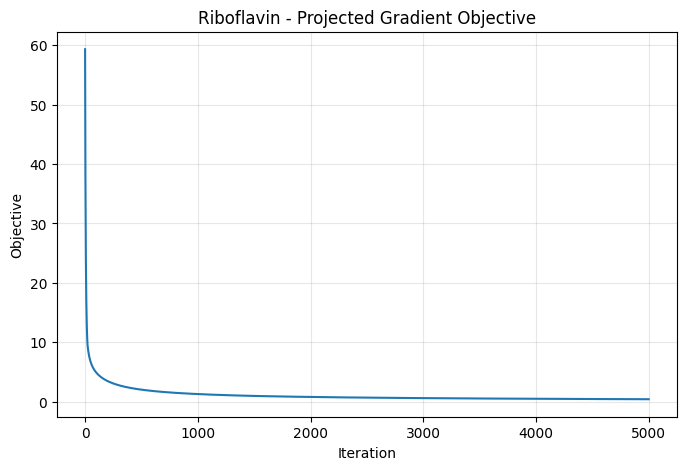

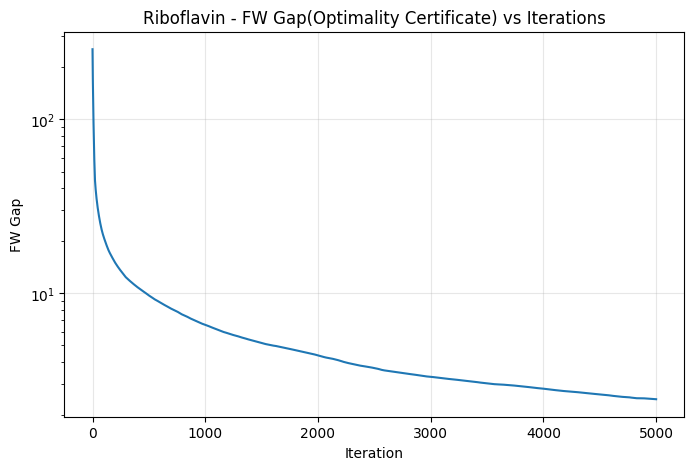

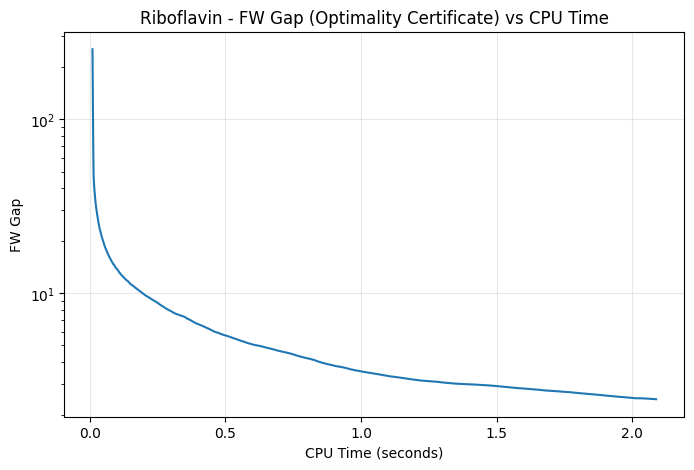

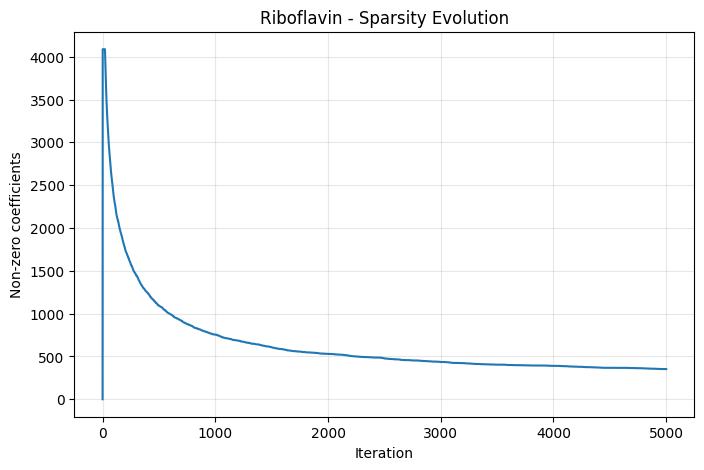

In [ ]:
plot_objective(
    pg_riboflavin,
    "Riboflavin"
)

plot_gap_iterations(
    pg_riboflavin,
    "Riboflavin"
)

plot_gap_runtime(
    pg_riboflavin,
    "Riboflavin"
)

plot_sparsity(
    pg_riboflavin,
    "Riboflavin"
)

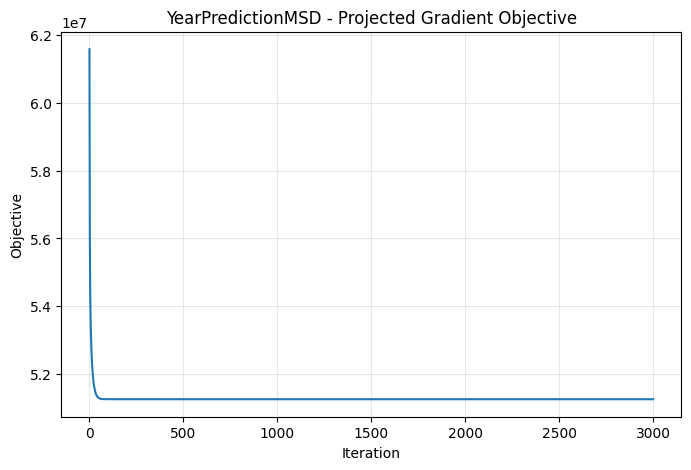

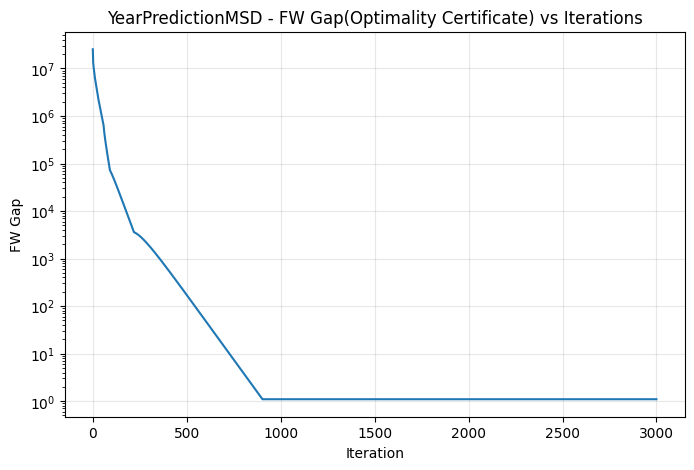

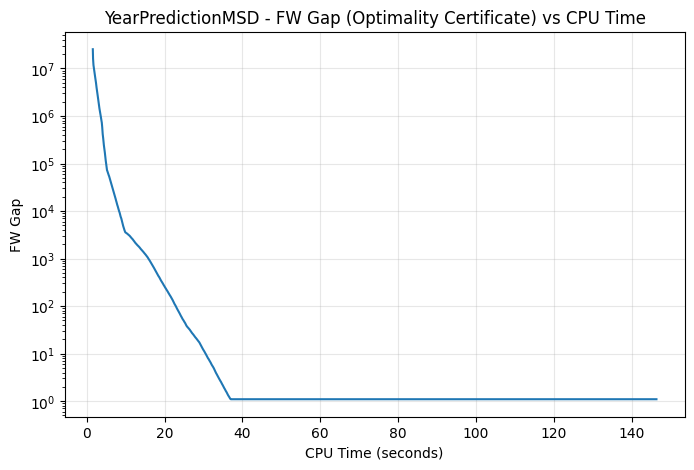

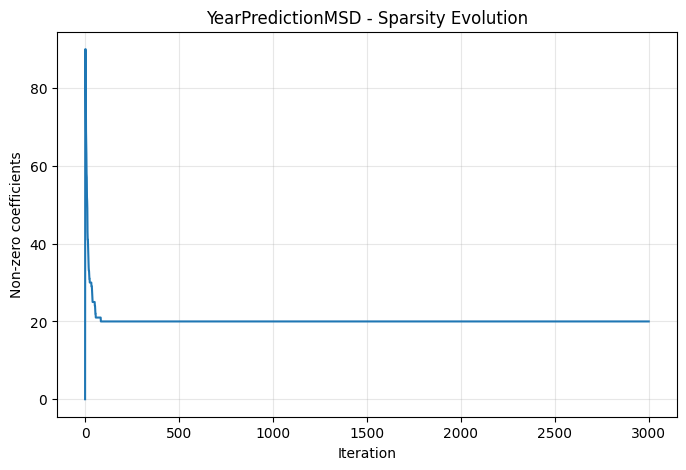

In [ ]:
plot_objective(
    pg_msd,
    "YearPredictionMSD"
)

plot_gap_iterations(
    pg_msd,
    "YearPredictionMSD"
)

plot_gap_runtime(
    pg_msd,
    "YearPredictionMSD"
)

plot_sparsity(
    pg_msd,
    "YearPredictionMSD"
)

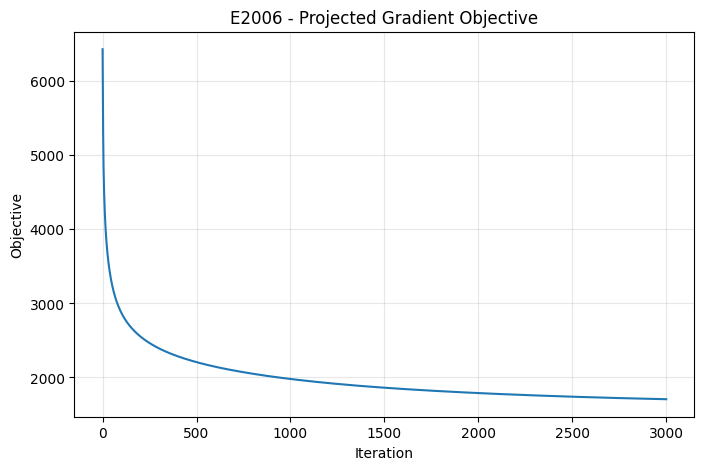

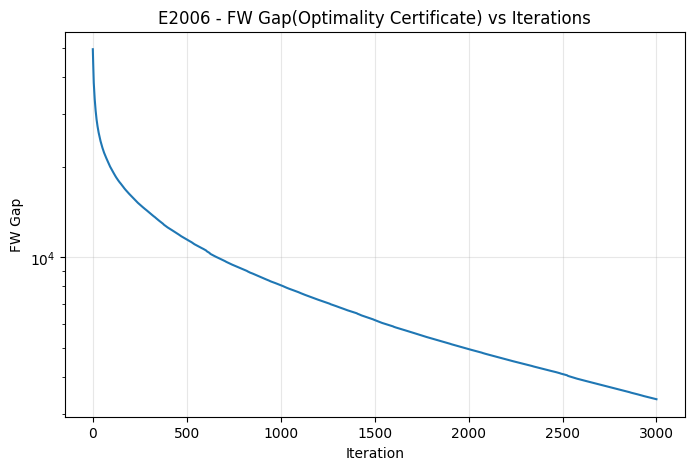

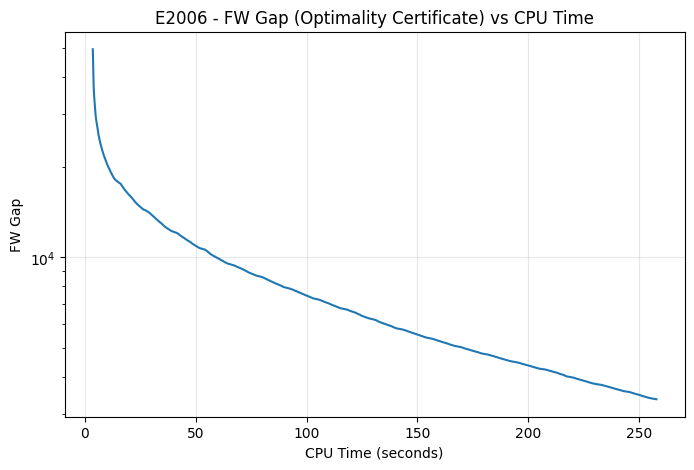

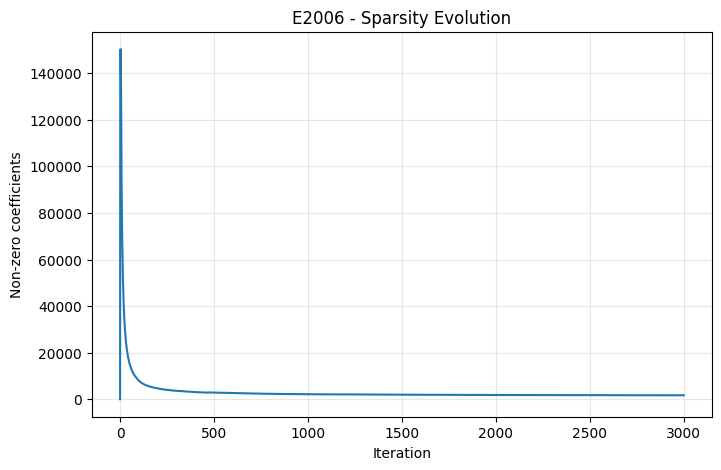

In [ ]:
plot_objective(
    pg_e2006,
    "E2006"
)

plot_gap_iterations(
    pg_e2006,
    "E2006"
)

plot_gap_runtime(
    pg_e2006,
    "E2006"
)

plot_sparsity(
    pg_e2006,
    "E2006"
)

In [ ]:
# ============================================================
# PROJECTED GRADIENT SUMMARY
# ============================================================

pg_summary = pd.DataFrame([

    {
        "Dataset":
            "Riboflavin",

        "Algorithm":
            "Projected Gradient",

        "Tau":
            pg_riboflavin["tau"],

        "Iterations":
            pg_riboflavin["iterations"],

        "Objective":
            pg_riboflavin["objective"],

        "FW Gap":
            pg_riboflavin["fw_gap"],

        "Runtime":
            pg_riboflavin["runtime"],

        "L1 Norm":
            pg_riboflavin["l1_norm"],

        "Non-zero":
            pg_riboflavin["nonzero"]
    },

    {
        "Dataset":
            "YearPredictionMSD",

        "Algorithm":
            "Projected Gradient",

        "Tau":
            pg_msd["tau"],

        "Iterations":
            pg_msd["iterations"],

        "Objective":
            pg_msd["objective"],

        "FW Gap":
            pg_msd["fw_gap"],

        "Runtime":
            pg_msd["runtime"],

        "L1 Norm":
            pg_msd["l1_norm"],

        "Non-zero":
            pg_msd["nonzero"]
    },

    {
        "Dataset":
            "E2006",

        "Algorithm":
            "Projected Gradient",

        "Tau":
            pg_e2006["tau"],

        "Iterations":
            pg_e2006["iterations"],

        "Objective":
            pg_e2006["objective"],

        "FW Gap":
            pg_e2006["fw_gap"],

        "Runtime":
            pg_e2006["runtime"],

        "L1 Norm":
            pg_e2006["l1_norm"],

        "Non-zero":
            pg_e2006["nonzero"]
    }
])

display(
    pg_summary
)

,Dataset,Algorithm,Tau,Iterations,Objective,FW Gap,Runtime,L1 Norm,Non-zero
0,Riboflavin,Projected Gradient,3.0,5000,0.4312752322488577,2.4523290716849626,2.0874884439999732,3.000000000000001,352
1,YearPredictionMSD,Projected Gradient,10.0,3000,51260896.556390986,1.0969451079145074,146.33343740300006,10.000000000000004,20
2,E2006,Projected Gradient,3.0,3000,1706.564596518379,3366.2013589774397,257.8100062970002,3.000000000000002,1694


In [ ]:
# ============================================================
# COMBINED ALGORITHM COMPARISON TABLE
# ============================================================

# Combine tables
comparison_summary = pd.concat(
    [fw_summary, pairwise_summary, pg_summary],ignore_index=True)

# Define desired ordering
dataset_order = [
    "Riboflavin",
    "YearPredictionMSD",
    "E2006"]

algorithm_order = [
    "Classic Frank-Wolfe",
    "Pairwise Frank-Wolfe",
    "Projected Gradient"]

comparison_summary["Dataset"] = pd.Categorical(
    comparison_summary["Dataset"],
    categories=dataset_order,
    ordered=True)

comparison_summary["Algorithm"] = pd.Categorical(
    comparison_summary["Algorithm"],
    categories=algorithm_order,
    ordered=True)

# Sort table
comparison_summary = comparison_summary.sort_values(
    ["Dataset", "Algorithm"]).reset_index(drop=True)

pd.set_option("display.float_format", str)

display(comparison_summary)

,Dataset,Algorithm,Tau,Iterations,Objective,FW Gap,Runtime,L1 Norm,Non-zero
0,Riboflavin,Classic Frank-Wolfe,3.0,5000,0.07802547465065938,0.14238447668855414,1.0649492739999005,2.9035580541416817,104
1,Riboflavin,Pairwise Frank-Wolfe,3.0,5000,0.02622199532656096,0.03431929469711714,0.6742486020002616,3.0000000000000004,83
2,Riboflavin,Projected Gradient,3.0,5000,0.4312752322488577,2.4523290716849626,2.0874884439999732,3.000000000000001,352
3,YearPredictionMSD,Classic Frank-Wolfe,10.0,3000,51276273.3303806,24214.56919964838,152.10552467299976,9.970672786711894,20
4,YearPredictionMSD,Pairwise Frank-Wolfe,10.0,263,51260896.55639085,9.041279554367065e-06,4.551759266999852,9.999999999999998,20
5,YearPredictionMSD,Projected Gradient,10.0,3000,51260896.556390986,1.0969451079145074,146.33343740300006,10.000000000000004,20
6,E2006,Classic Frank-Wolfe,3.0,3000,1734.2318037312084,225.71802031507445,275.1054881260002,2.6092318814460636,380
7,E2006,Pairwise Frank-Wolfe,3.0,3000,1611.9464917360895,10.669547275206469,342.23016227100015,3.0000000000000018,659
8,E2006,Projected Gradient,3.0,3000,1706.564596518379,3366.2013589774397,257.8100062970002,3.000000000000002,1694
